# 06b — Visual Analysis & Statistical Tests (v1.0-trainval, 5-fold)
## Multi-Attribute Scene Classification on nuScenes — Primary Experiment

Confusion matrices, ROC/AUC, tuning significance (paired Wilcoxon + Cohen's d), pairwise model
comparisons, per-fold variability, and difficulty tiers — all on the 150-scene subset.

> Statistical tests here are **within-stage** (comparing models/versions on the same trainval data,
> paired across folds) — this is valid, unlike cross-stage comparison. Reads saved results + models.


## 0. Setup

In [2]:
import os, json, joblib
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score
from scipy.stats import wilcoxon

def find_project_root():
    p=Path.cwd().resolve()
    for cand in [p,*p.parents]:
        if (cand/'README.md').exists() and (cand/'notebooks').exists(): return cand
    raise FileNotFoundError('Project root not found')
os.chdir(find_project_root())
sns.set_theme(style='whitegrid',context='notebook'); plt.rcParams['figure.dpi']=100
DV='v1.0-trainval'
RESULTS_DIR=Path('results')/DV/'metrics'; PRED_DIR=Path('results')/DV/'predictions'
MODELS_DIR=Path('models')/DV; FINAL_DIR=Path('results')/DV/'final'; FINAL_DIR.mkdir(parents=True,exist_ok=True)
FIG_DIR=Path('results')/DV/'figures'/'final'; FIG_DIR.mkdir(parents=True,exist_ok=True)
FEATURE_DIR=Path('data/processed')/DV/'features'
ATTRIBUTES=['time_of_day','weather','vehicle_density','vru_present']
CLASS_ORDERS={'time_of_day':['day','night'],'weather':['clear','rain'],
              'vehicle_density':['low','medium','high'],'vru_present':['absent','present']}
DISPLAY={'LogisticRegression':'LogReg','SVM_RBF':'SVM','RandomForest':'RF','XGBoost':'XGB','MLP':'MLP'}
SEED_FOR_VIS=42
print('Setup OK |',os.getcwd())

Setup OK | C:\Users\leemi\Documents\GitHub\nuscenes-scene-classification-ml


## 1. Load + Identify Best Tuned Model per Attribute

In [3]:
df_metrics=pd.read_csv(RESULTS_DIR/'all_metrics.csv')
df_preds=pd.read_csv(PRED_DIR/'predictions_test.csv')
tuned=df_metrics[df_metrics.version=='tuned']
best_models={}
for attr in ATTRIBUTES:
    g=tuned[tuned.attribute==attr].groupby('model')['macro_f1'].mean()
    if len(g): best_models[attr]=g.idxmax()
print('Best tuned model per attribute:')
for a,m in best_models.items(): print(f'  {a:18s}: {DISPLAY.get(m,m)}')

Best tuned model per attribute:
  time_of_day       : XGB
  weather           : RF
  vehicle_density   : SVM
  vru_present       : SVM


## 2. Confusion Matrices (5-fold out-of-fold, seed 42)

In k-fold CV each sample is tested once; aggregating all folds at seed 42 gives full-dataset coverage.

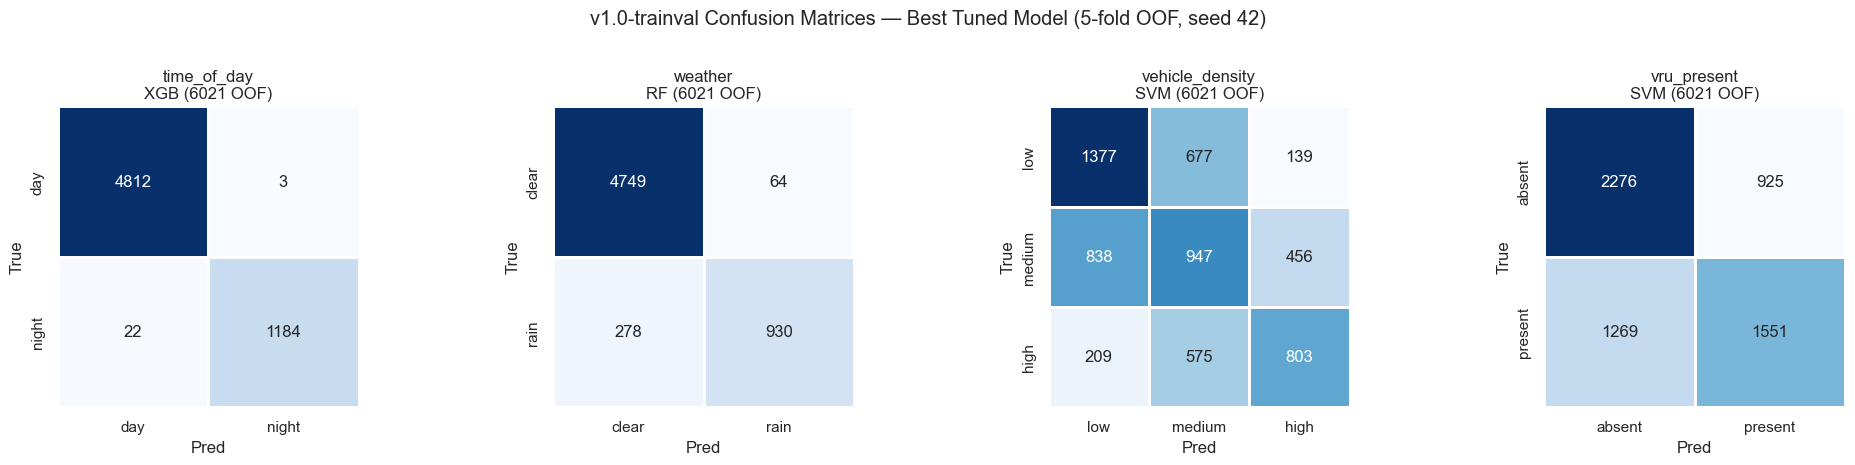

In [4]:
fig,axes=plt.subplots(1,4,figsize=(20,4.5))
for ax,attr in zip(axes,ATTRIBUTES):
    m=best_models[attr]; classes=CLASS_ORDERS[attr]
    sub=df_preds[(df_preds.attribute==attr)&(df_preds.model==m)&
                 (df_preds.version=='tuned')&(df_preds.seed==SEED_FOR_VIS)]
    cm=confusion_matrix(sub.y_true,sub.y_pred,labels=classes)
    sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',cbar=False,xticklabels=classes,
                yticklabels=classes,ax=ax,square=True,linewidths=1)
    ax.set_title(f'{attr}\n{DISPLAY.get(m,m)} ({len(sub)} OOF)'); ax.set_xlabel('Pred'); ax.set_ylabel('True')
plt.suptitle('v1.0-trainval Confusion Matrices — Best Tuned Model (5-fold OOF, seed 42)',y=1.02)
plt.tight_layout(); plt.savefig(FIG_DIR/'confusion_matrices.png',bbox_inches='tight',dpi=120); plt.show()

## 3. ROC Curves + AUC (binary attributes)

Uses saved models' probabilities on each fold's test set (seed 42).

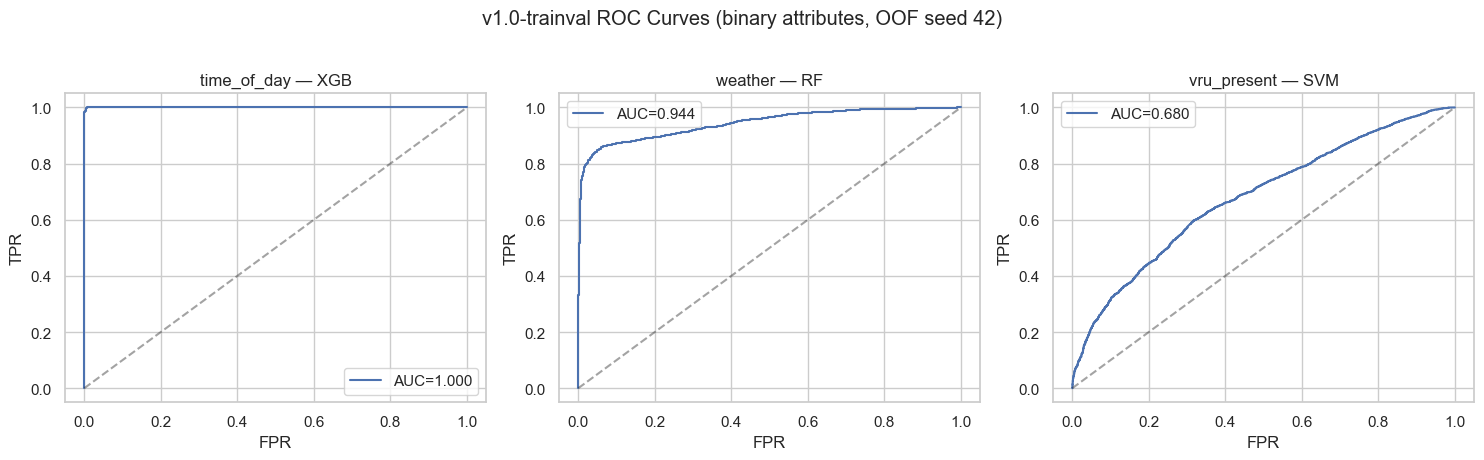

  attribute model   auc
time_of_day   XGB 1.000
    weather    RF 0.944
vru_present   SVM 0.680


In [5]:
# Reconstruct features keyed by sample_token to score saved models
feat=pd.read_csv(FEATURE_DIR/'features_full.csv')
feat_cols=[col for col in feat.columns if col.startswith(('hog_','color_','lbp_','photo_'))]
folds=pd.read_csv(Path('data/processed')/DV/'splits'/'sample_fold_assignments.csv')
feat=feat.merge(folds[['sample_token','fold']],on='sample_token')

binary_attrs=[a for a in ATTRIBUTES if len(CLASS_ORDERS[a])==2]
fig,axes=plt.subplots(1,len(binary_attrs),figsize=(5*len(binary_attrs),4.5))
if len(binary_attrs)==1: axes=[axes]
roc_summary=[]
for ax,attr in zip(axes,binary_attrs):
    m=best_models[attr]; classes=CLASS_ORDERS[attr]
    # aggregate OOF probabilities across folds at seed 42
    y_true_all=[]; y_score_all=[]
    for fold in sorted(feat.fold.unique()):
        mp=MODELS_DIR/attr/f'{m}_tuned_seed{SEED_FOR_VIS}_fold{fold}.pkl'
        if not mp.exists(): continue
        bundle=joblib.load(mp); model=bundle['model']; le=bundle['label_encoder']
        # merge labels for this attr from predictions (true labels) via sample_token
        test_rows=feat[feat.fold==fold]
        lab=df_preds[(df_preds.attribute==attr)&(df_preds.model==m)&(df_preds.version=='tuned')&
                     (df_preds.seed==SEED_FOR_VIS)&(df_preds.fold==fold)][['sample_token','y_true']]
        merged=test_rows.merge(lab,on='sample_token')
        if merged.empty: continue
        proba=model.predict_proba(merged[feat_cols].values)[:,1]
        y_true_all.extend((merged.y_true==classes[1]).astype(int).tolist())
        y_score_all.extend(proba.tolist())
    if len(set(y_true_all))<2: 
        ax.text(0.5,0.5,f'{attr}\ninsufficient',ha='center'); continue
    fpr,tpr,_=roc_curve(y_true_all,y_score_all); auc=roc_auc_score(y_true_all,y_score_all)
    ax.plot(fpr,tpr,label=f'AUC={auc:.3f}'); ax.plot([0,1],[0,1],'k--',alpha=.4)
    ax.set_title(f'{attr} — {DISPLAY.get(m,m)}'); ax.set_xlabel('FPR'); ax.set_ylabel('TPR'); ax.legend()
    roc_summary.append({'attribute':attr,'model':DISPLAY.get(m,m),'auc':round(auc,3)})
plt.suptitle('v1.0-trainval ROC Curves (binary attributes, OOF seed 42)',y=1.02)
plt.tight_layout(); plt.savefig(FIG_DIR/'roc_curves.png',bbox_inches='tight',dpi=120); plt.show()
print(pd.DataFrame(roc_summary).to_string(index=False) if roc_summary else 'no ROC computed')

## 4. Tuning Significance (base vs tuned, paired Wilcoxon + Cohen's d)

Paired across the 15 (fold × seed) observations per model — valid within-stage test.

In [6]:
def cohens_d(a,b):
    a,b=np.asarray(a),np.asarray(b); diff=a-b
    return float(diff.mean()/diff.std(ddof=1)) if diff.std(ddof=1)>0 else 0.0
rows=[]
for attr in ATTRIBUTES:
    for model in df_metrics.model.unique():
        base=df_metrics[(df_metrics.attribute==attr)&(df_metrics.model==model)&(df_metrics.version=='base')].sort_values(['seed','fold'])['macro_f1'].values
        tun =df_metrics[(df_metrics.attribute==attr)&(df_metrics.model==model)&(df_metrics.version=='tuned')].sort_values(['seed','fold'])['macro_f1'].values
        if len(base)!=len(tun) or len(base)<3: continue
        try: stat,p=wilcoxon(tun,base)
        except Exception: p=np.nan
        rows.append({'attribute':attr,'model':DISPLAY.get(model,model),
                     'base_mean':round(base.mean(),3),'tuned_mean':round(tun.mean(),3),
                     'delta':round(tun.mean()-base.mean(),3),'cohens_d':round(cohens_d(tun,base),3),
                     'p_value':round(p,4) if not np.isnan(p) else None})
df_tune=pd.DataFrame(rows); df_tune.to_csv(FINAL_DIR/'tuning_significance.csv',index=False)
print('=== TUNING SIGNIFICANCE (base vs tuned) ==='); print(df_tune.to_string(index=False))

=== TUNING SIGNIFICANCE (base vs tuned) ===
      attribute  model  base_mean  tuned_mean  delta  cohens_d  p_value
    time_of_day LogReg      0.993       0.993 -0.000    -0.092   0.6108
    time_of_day    SVM      0.978       0.978  0.000     0.000      NaN
    time_of_day     RF      0.975       0.976  0.001     0.537   0.0431
    time_of_day    XGB      0.991       0.993  0.002     0.477   0.1025
    time_of_day    MLP      0.969       0.969 -0.001    -0.116   1.0000
        weather LogReg      0.852       0.858  0.007     0.366   0.2099
        weather    SVM      0.873       0.876  0.003     0.483   0.0989
        weather     RF      0.893       0.901  0.008     0.409   0.1688
        weather    XGB      0.889       0.896  0.007     0.511   0.1244
        weather    MLP      0.854       0.850 -0.004    -0.350   0.2626
vehicle_density LogReg      0.473       0.486  0.014     1.075   0.0103
vehicle_density    SVM      0.519       0.511 -0.008    -0.551   0.0401
vehicle_density     

c:\Users\leemi\.pyenv\pyenv-win\versions\3.12.10\Lib\site-packages\scipy\stats\_wilcoxon.py:181: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se


## 5. Per-Fold Variability Boxplots

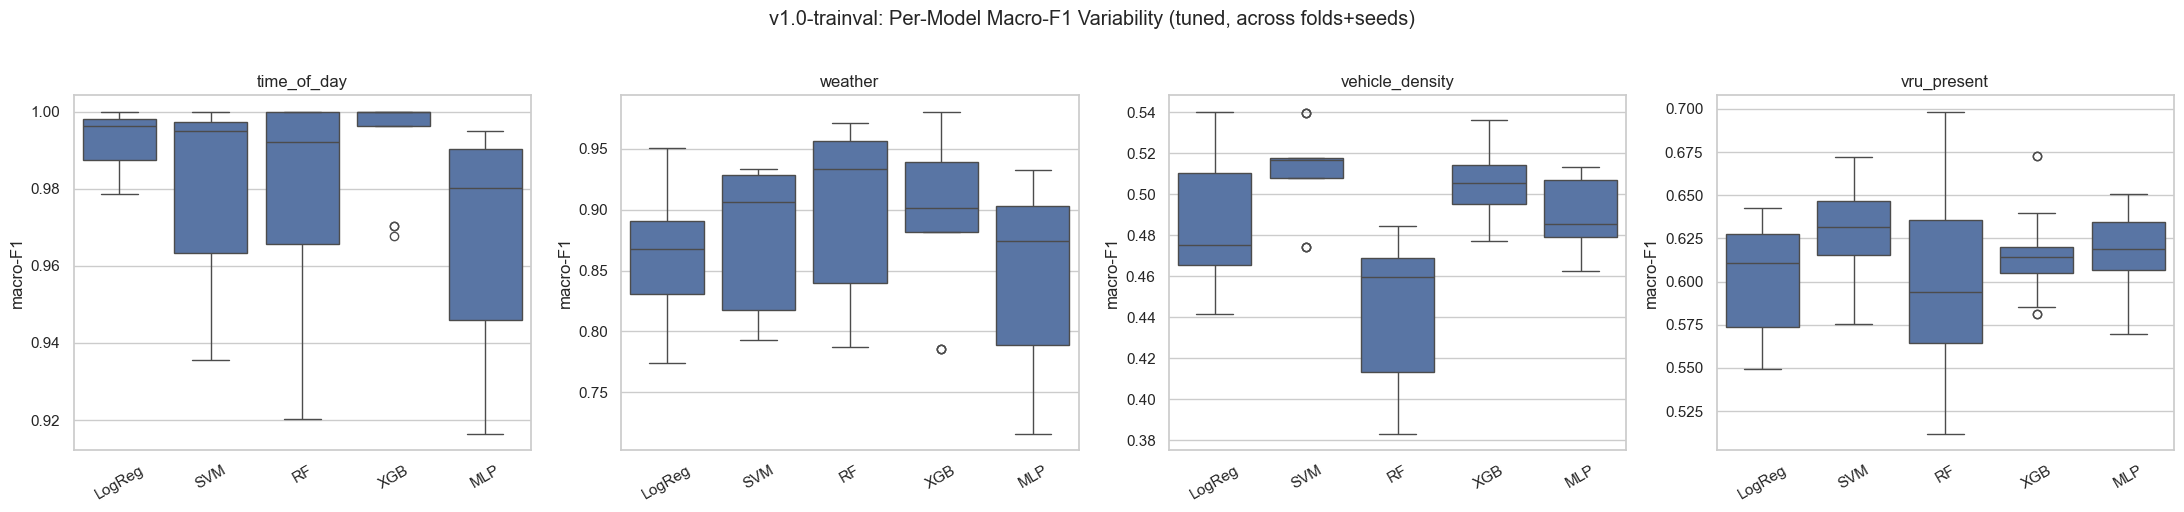

In [7]:
fig,axes=plt.subplots(1,4,figsize=(22,5))
for ax,attr in zip(axes,ATTRIBUTES):
    sub=tuned[tuned.attribute==attr].copy(); sub['model_s']=sub.model.map(lambda m:DISPLAY.get(m,m))
    sns.boxplot(data=sub,x='model_s',y='macro_f1',ax=ax)
    ax.set_title(attr); ax.set_xlabel(''); ax.set_ylabel('macro-F1'); ax.tick_params(axis='x',rotation=30)
plt.suptitle('v1.0-trainval: Per-Model Macro-F1 Variability (tuned, across folds+seeds)',y=1.02)
plt.tight_layout(); plt.savefig(FIG_DIR/'variability_boxplots.png',bbox_inches='tight',dpi=120); plt.show()

## 6. Difficulty-Tier Analysis

=== ATTRIBUTE DIFFICULTY TIERS (tuned, all models) ===
                  mean    std    min    max
attribute                                  
time_of_day      0.982  0.024  0.916  1.000
weather          0.876  0.065  0.716  0.980
vru_present      0.612  0.039  0.512  0.698
vehicle_density  0.487  0.036  0.383  0.540


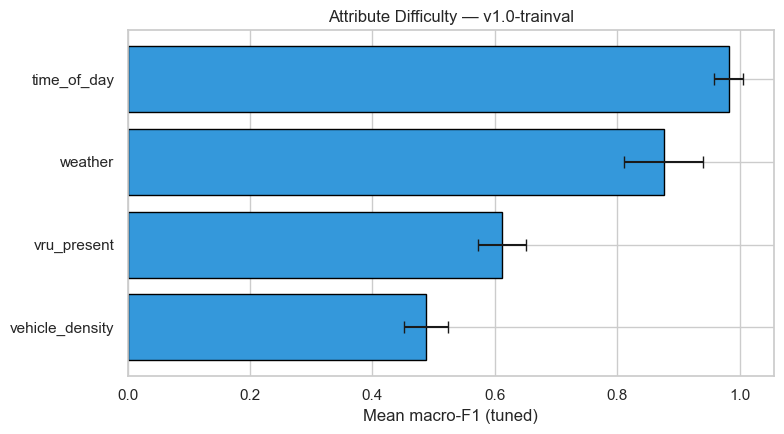

In [8]:
diff=(tuned.groupby('attribute')['macro_f1'].agg(['mean','std','min','max']).round(3)
      .sort_values('mean',ascending=False))
print('=== ATTRIBUTE DIFFICULTY TIERS (tuned, all models) ==='); print(diff)
fig,ax=plt.subplots(figsize=(8,4.5))
ax.barh(diff.index,diff['mean'],xerr=diff['std'],color='#3498db',edgecolor='black',capsize=4)
ax.set_xlabel('Mean macro-F1 (tuned)'); ax.set_title('Attribute Difficulty — v1.0-trainval'); ax.invert_yaxis()
plt.tight_layout(); plt.savefig(FIG_DIR/'difficulty_tiers.png',bbox_inches='tight',dpi=120); plt.show()

## Findings (write in your own words)
[WRITE: confusion-matrix diagnosis (which classes confuse); AUC for binary attributes; whether tuning
significantly helped (p-values, Cohen's d) — likely small/mixed gains; difficulty tiers
(photometric easy, structural hard). Tie to the feature-ceiling argument.]